In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob
import sklearn as sk


In [19]:
data_path = r"..\data\data_1504.csv" if os.name == "nt" else "../data/data_1504.csv"

if not os.path.exists(data_path):
    matches = glob.glob("**/data_1504.csv", recursive=True)
    if matches:
        data_path = matches[0]
    else:
        for root, _, files in os.walk("."):
            if "data_1504.csv" in files:
                data_path = os.path.join(root, "data_1504.csv")
                break

if not os.path.exists(data_path):
    raise FileNotFoundError(
        "data_1504.csv not found. Place the file in the notebook directory or specify the correct path."
    )

df = pd.read_csv(data_path)
print(f"Loaded data from: {data_path}")


Loaded data from: ..\data\data_1504.csv


In [20]:
def MeanVariance(df):
    mean = df.mean()
    variance = df.var()
    return mean, variance
mean, variance = MeanVariance(df)
print("Mean:\n", mean)
print("\nVariance:\n", variance)


Mean:
 Unnamed: 0    49.500000
A              0.986614
B              0.188122
C              0.184530
D              1.518491
dtype: float64

Variance:
 Unnamed: 0    841.666667
A               3.474921
B               0.399532
C               1.679215
D               4.283746
dtype: float64


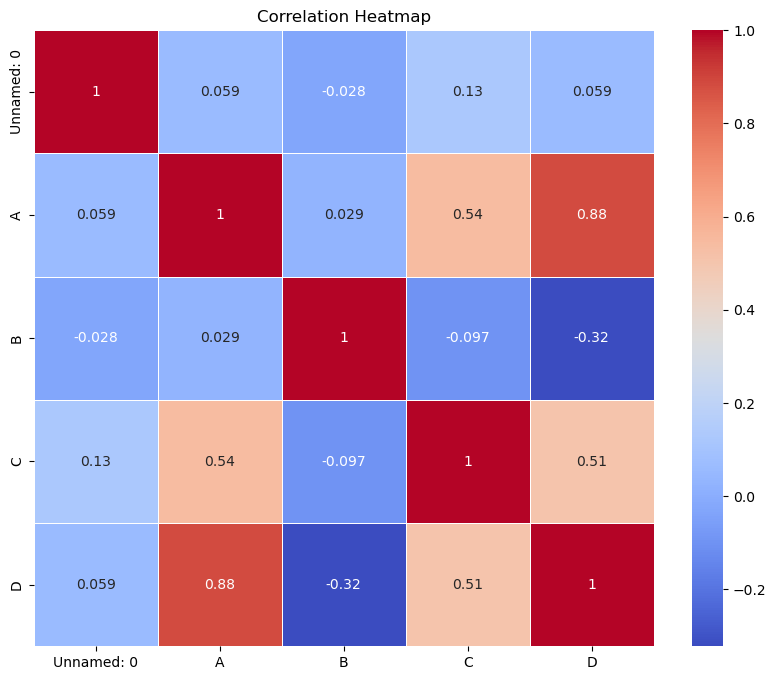

In [29]:


heatmap_data = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


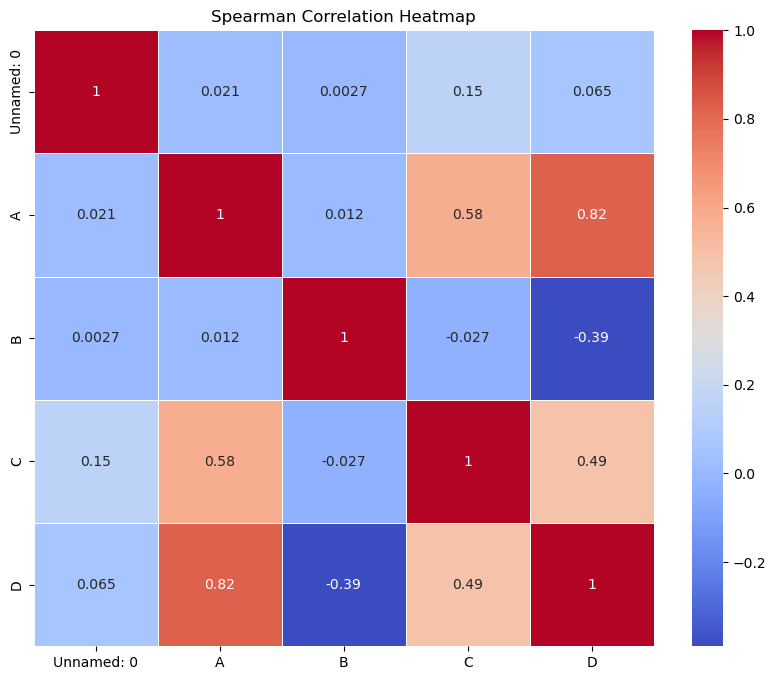

In [39]:
def spearman_heatmap(df):
    spearman_corr = df.corr(method='spearman')
    plt.figure(figsize=(10, 8))
    sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", linewidths=0.5)
    plt.title("Spearman Correlation Heatmap")
    plt.show()
spearman_heatmap(df)

<Axes: >

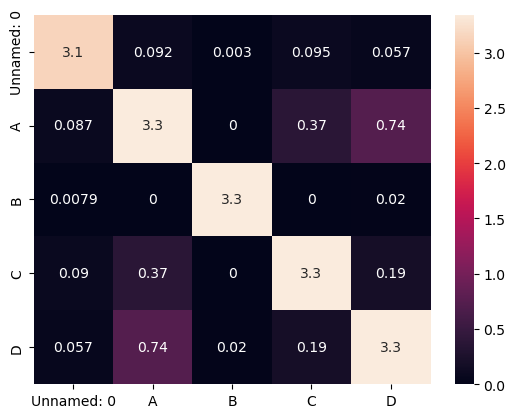

In [48]:
from sklearn.feature_selection import mutual_info_regression

def calculate_mi_matrix(df):
    variables = df.columns
    mi_matrix = pd.DataFrame(index=variables, columns=variables)
    
    for i in variables:
        for j in variables:
            # Vi beregner MI mellem variabel i og j
            # Reshape er nødvendig for sklearn
            mi = mutual_info_regression(df[[i]], df[j], random_state=42)
            mi_matrix.loc[i, j] = mi[0]
            
    return mi_matrix.astype(float)

# Kør den på jeres baseline data
mi_results = calculate_mi_matrix(df)
sns.heatmap(mi_results, annot=True)

Loaded intervention data from: ..\data\-2a.csv


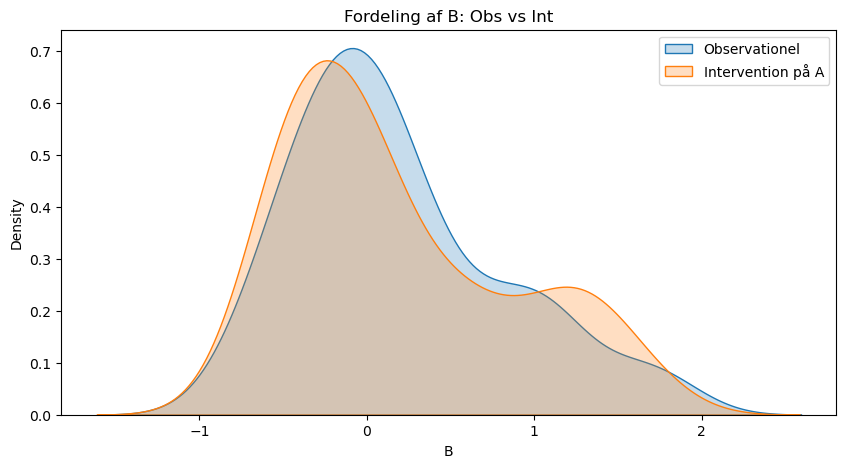

In [36]:
def check_confounder(obs_df, int_df_a, var_target='B'):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(obs_df[var_target], label='Observationel', fill=True)
    sns.kdeplot(int_df_a[var_target], label=f'Intervention på A', fill=True)
    plt.legend()
    plt.title(f"Fordeling af {var_target}: Obs vs Int")
    plt.show()

data_path_int = r"..\data\-2a.csv" if os.name == "nt" else "../data/-2a.csv"
df_int = pd.read_csv(data_path_int)
print(f"Loaded intervention data from: {data_path_int}")


check_confounder(df, df_int, var_target='B')

In [46]:
def estimate_ace(df_high, df_low, target_var):
    """
    Estimate the Average Causal Effect (ACE) of a treatment variable on a target variable.
    
    Parameters:
    df_high (pd.DataFrame): DataFrame with high treatment values
    df_low (pd.DataFrame): DataFrame with low treatment values
    target_var (str): Name of the target variable
    # Average Causal Effect (ACE) estimation

    # ACE > 0: X har en positiv effekt på Y (X op -> Y op).
    # ACE < 0: X har en negativ effekt på Y (X op -> Y ned).
    # ACE = 0: X har ingen kausal effekt på Y 
    
    Returns:
    float: The estimated ACE
    """     
    # E[Y | do(X=2)] - E[Y | do(X=-2)] divideret med afstanden i X (4)
    ace = (df_high[target_var].mean() - df_low[target_var].mean()) / 4
    return ace

data_path_high = r"..\data\2a.csv" if os.name == "nt" else "../data/2a.csv"
data_path_low = r"..\data\-2a.csv" if os.name == "nt" else "../data/-2a.csv"
df_high = pd.read_csv(data_path_high)

df_low = pd.read_csv(data_path_low)

ace_estimate = estimate_ace(df_high, df_low, target_var='C')

print(f"Estimated ACE of A on C: {ace_estimate:.3f}")

Estimated ACE of A on C: 0.053


In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


def estimate_causal_effect_hybrid(df, treatment_col, outcome_col, confounder_cols=None, random_state=42):
    """
    Estimerer en kausal effekt med en hybrid/double-machine-learning stil:
    - fleksibel model til at fange lineære og ikke-lineære mønstre i confounders
    - residualisering af både treatment og outcome
    - lineær regression på residualerne for at få treatment-effekten

    Dette er mere fleksibelt end ren lineær regression, men er stadig afhængigt af
    antagelsen om, at de vigtigste confounders er med i data.
    """
    if confounder_cols is None:
        confounder_cols = [c for c in df.columns if c not in [treatment_col, outcome_col]]

    use_cols = [treatment_col, outcome_col] + confounder_cols
    data = df[use_cols].dropna().copy()

    if len(confounder_cols) == 0:
        raise ValueError("Der skal være mindst én confounder-kolonne for denne metode.")

    X_conf = data[confounder_cols]
    t = data[treatment_col].to_numpy()
    y = data[outcome_col].to_numpy()

    # Fleksible modeller til at fange både lineære og ikke-lineære relationer
    y_model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        min_samples_leaf=5,
    )
    t_model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        min_samples_leaf=5,
    )

    y_model.fit(X_conf, y)
    t_model.fit(X_conf, t)

    y_residual = y - y_model.predict(X_conf)
    t_residual = t - t_model.predict(X_conf)

    final_model = LinearRegression()
    final_model.fit(t_residual.reshape(-1, 1), y_residual)

    return {
        "causal_effect": final_model.coef_[0],
        "intercept": final_model.intercept_,
        "outcome_model": y_model,
        "treatment_model": t_model,
        "final_model": final_model,
        "used_columns": use_cols,
    }


# Vælg selv hvilke kolonner der er treatment og outcome
# Eksempel: treatment_col = "..." og outcome_col = "..."
# Hvis du bare vil teste hurtigt, kan du bruge to numeriske kolonner
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    treatment_col = numeric_cols[1] # 0 = 0, 1 = A, 2 = B, 3 = C, 4 = D
    outcome_col = numeric_cols[2]
    confounder_cols = [c for c in numeric_cols if c not in [treatment_col, outcome_col]]

    inverse_treatment_col = outcome_col
    inverse_outcome_col = treatment_col
    inverse_result = estimate_causal_effect_hybrid(df, inverse_treatment_col, inverse_outcome_col, confounder_cols)

    result = estimate_causal_effect_hybrid(df, treatment_col, outcome_col, confounder_cols)
    print(f"Treatment: {treatment_col}")
    print(f"Outcome: {outcome_col}")
    print(f"Estimeret hybrid kausal effekt: {result['causal_effect']:.4f}")

    print(f"\nInvers test (omvendt treatment og outcome):")
    print(f"Treatment: {inverse_treatment_col}")
    print(f"Outcome: {inverse_outcome_col}")
    print(f"Estimeret hybrid kausal effekt: {inverse_result['causal_effect']:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre eksemplet.")


Treatment: A
Outcome: B
Estimeret hybrid kausal effekt: 0.3294

Invers test (omvendt treatment og outcome):
Treatment: B
Outcome: A
Estimeret hybrid kausal effekt: 0.9123


## C. Invarians-test (Invariant Causal Prediction)

Idéen er, at hvis en variabel virkelig er en årsag til en target `Y`, så bør sammenhængen mellem dem være mere stabil på tværs af forskellige miljøer eller interventioner.

- Hvis `Y` ændrer sig, når vi skifter miljø for en kandidatvariabel `X`, tyder det på en kausal relation.
- Hvis fordelingen af `Y` er nogenlunde den samme på tværs af miljøer for en variabel `Z`, er `Z` mindre sandsynligt en direkte årsag til `Y`.

Nedenfor er en enkel invarians-test, som sammenligner middelværdien af residualer på tværs af miljøer. Den er ikke en fuld ICP-implementering, men den giver en praktisk og let forståelig test i notebooken.

In [26]:
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression


def icp_invariance_test(df, target_col, cause_col, confounder_cols=None, env_col=None, n_env=3, alpha=0.05):
    """
    Enkel invarians-test inspireret af Invariant Causal Prediction.

    Idé:
    - Del data op i miljøer (environments)
    - Fit en model for target ud fra kandidat-variabler
    - Test om residualerne er ens på tværs af miljøer

    Hvis residualerne ikke ser forskellige ud mellem miljøerne, er relationen mere stabil.
    """
    if confounder_cols is None:
        confounder_cols = [c for c in df.columns if c not in [target_col, cause_col, env_col]]

    cols = [target_col, cause_col] + confounder_cols
    if env_col is not None:
        cols.append(env_col)

    data = df[cols].dropna().copy()

    if env_col is None:
        # Skab kunstige miljøer ved at opdele cause_col i kvantiler
        data["environment"] = pd.qcut(data[cause_col], q=n_env, labels=False, duplicates="drop")
        env_col = "environment"

    X = data[[cause_col] + confounder_cols]
    y = data[target_col]
    env = data[env_col]

    model = LinearRegression()
    model.fit(X, y)
    residuals = y - model.predict(X)

    groups = [residuals[env == g] for g in sorted(env.unique())]
    groups = [g for g in groups if len(g) > 1]

    if len(groups) < 2:
        raise ValueError("Der skal være mindst to miljøer med mere end én observation hver.")

    stat, p_value = f_oneway(*groups)
    invariant = p_value > alpha

    return {
        "invariant": invariant,
        "p_value": p_value,
        "statistic": stat,
        "residual_model": model,
        "used_columns": cols,
    }


# Eksempel: brug første numeriske kolonne som kandidat-årsag og anden som target
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    cause_col = numeric_cols[0]
    target_col = numeric_cols[1]
    confounder_cols = [c for c in numeric_cols if c not in [cause_col, target_col]]

    icp_result = icp_invariance_test(df, target_col, cause_col, confounder_cols=confounder_cols)
    print(f"Cause candidate: {cause_col}")
    print(f"Target: {target_col}")
    print(f"Invariant relation: {icp_result['invariant']}")
    print(f"p-værdi: {icp_result['p_value']:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre invarians-testen.")

Cause candidate: Unnamed: 0
Target: A
Invariant relation: True
p-værdi: 0.9378


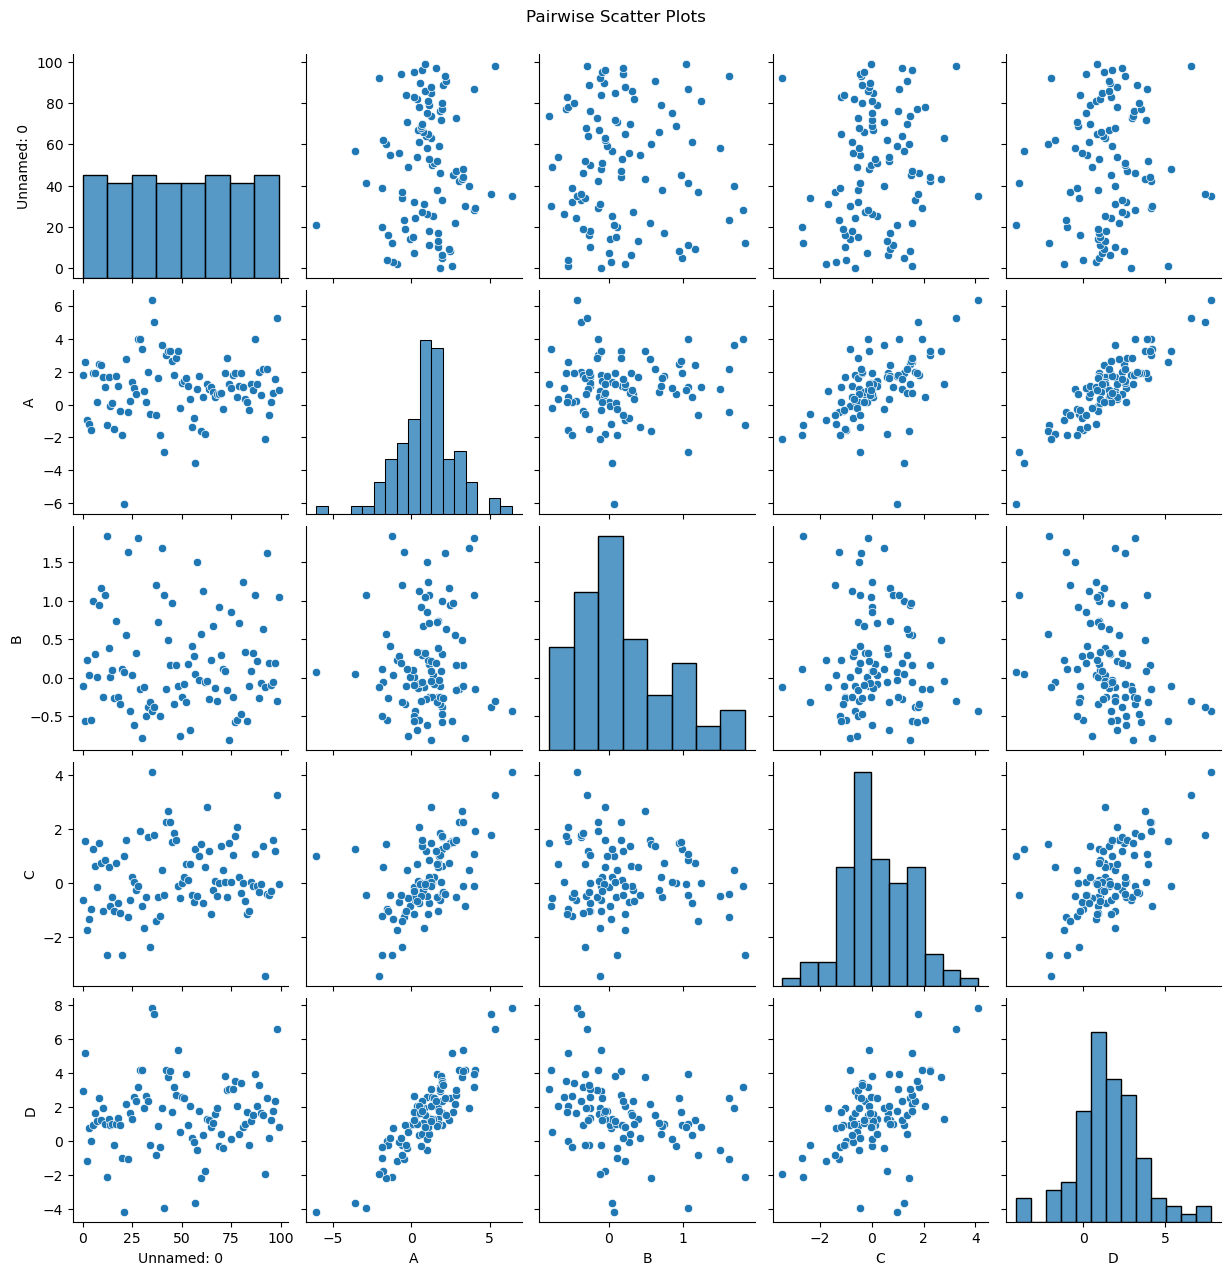

In [41]:
def pairwise_scatter(df):
    sns.pairplot(df)
    plt.suptitle("Pairwise Scatter Plots", y=1.02)
    plt.show()
pairwise_scatter(df)

# efter at have kigget på correlation, kan man lave en intervention der på hvor fordelingen mangler